# Import cleaned 2024 Turkish scraped Used Card data
# "2024_turkey_car_market_ML.csv" as "df_2024"

In [1]:
#If needed, install modules
#!pip install rapidfuzz
#!pip install joblib

Let's estimate your car's value. Please enter:

Available makes: Alfa Romeo (212), Audi (1891), BMW (2670), Bentley (8), Chery (5), Chevrolet (1356), Citroen (2311), Dacia (1156), Ferrari (4), Fiat (7126), Ford (5401), GMC (1), Honda (2727), Hyundai (3963), Isuzu (2), Jaguar (58), Jeep (3), Kia (949), Lada (333), Land Rover (9), Lincoln (1), MINI (159), Maserati (21), Mazda (398), Mercedes (2292), Mitsubishi (302), Nissan (727), Opel (5788), Peugeot (2994), Porsche (74), Renault (8961), Rolls-Royce (3), Rover (85), Seat (1782), Skoda (2139), Smart (1), Subaru (57), Suzuki (251), Tata (110), Tofaş (2240), Toyota (2938), Volkswagen (8678), Volvo (662)


Make:  vw


Corrected Make: Volkswagen

Available models for Volkswagen: Amarok (3), Arteon (4), Bora (87), Caddy (14), Caravelle (1), EOS (1), Golf (2194), Jetta (1544), MultiVan (1), New Beetle (12), Passat (2359), Passat Alltrack (1), Passat Variant (18), Polo (2334), Scirocco (20), The Beetle (2), Tiguan (5), Tiguan All Space (1), Touran (8), Transporter (14), VW CC (53), Vento (2)


Model:  jetta


Matching 'Jetta' against choices: ('Jetta', 100.0, 7)
Corrected Model: Jetta



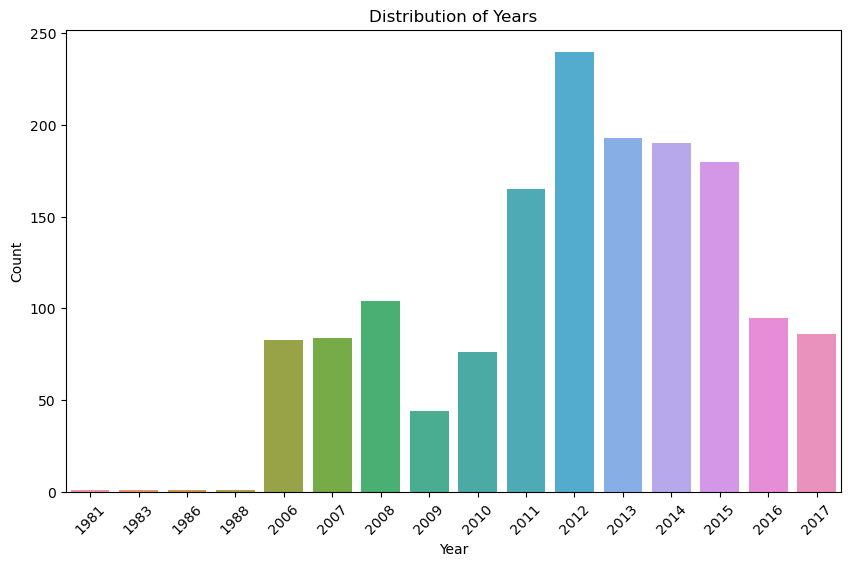

Available years: 1981 - 2017


Year:  2014


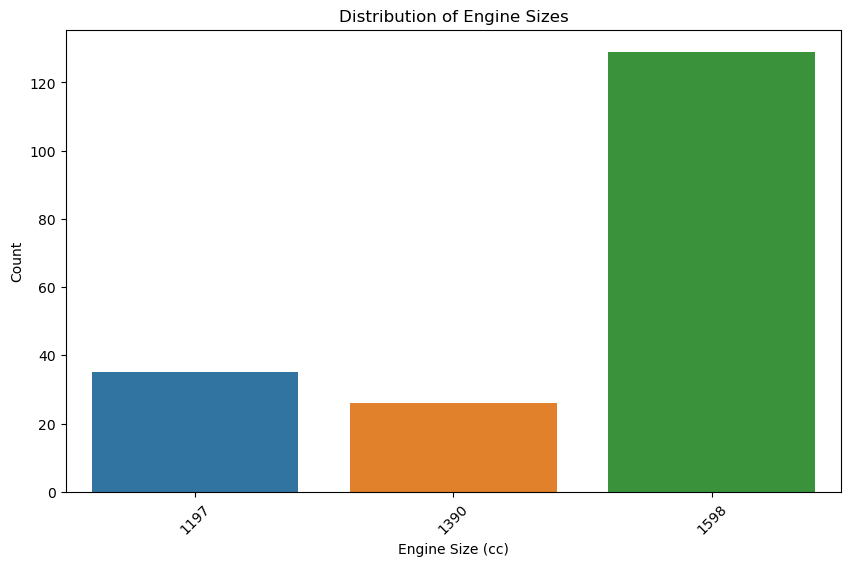

Available Engine sizes (cc): 1197 - 1598


Engine Size (cc):  1598


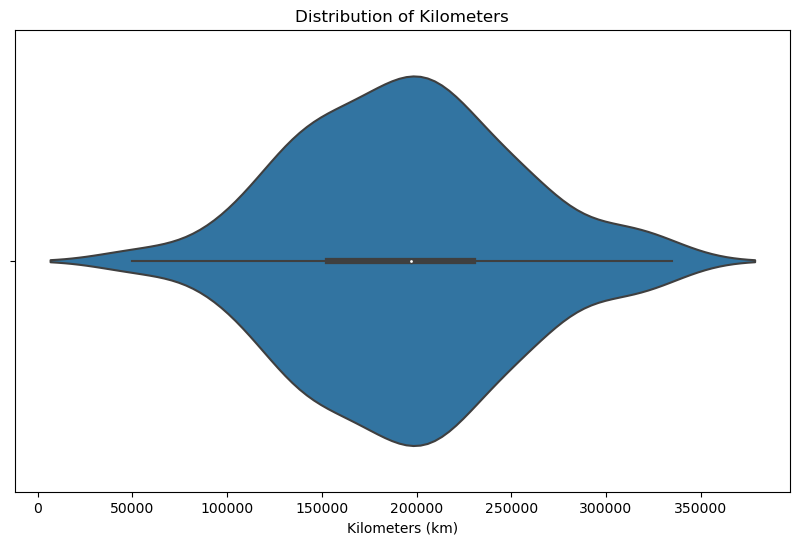

Available Kilometers: 50000 - 335000


Kilometers:  135000


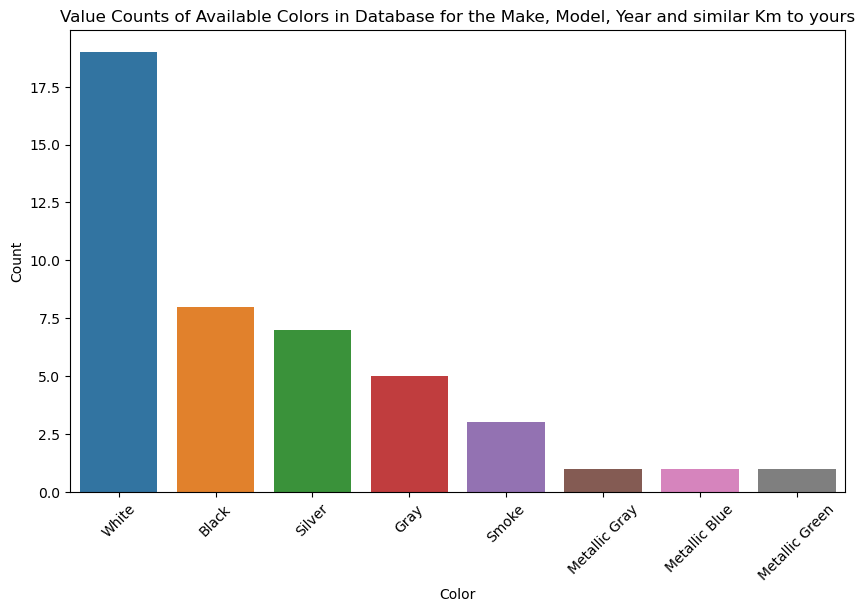

Available colors: Beige, Black, Blue, Brown, Dark Red, Gray, Metallic Blue, Metallic Gray, Metallic Green, Navy Blue, Red, Silver, Smoke, Titanium Gray, White


Color:  white


Matching 'White' against choices: ('White', 100.0, 14)
Corrected Color: White

Transmission:
a: Semi-Automatic (55)
b: Manual (28)


Select a transmission option:  a



Body Type:
a: Sedan (54)
b: Station wagon (1)


Select a body type option:  a



Available fuel types:
a: Diesel (34)
b: Gasoline (20)


Select a fuel type option:  a



Traction: Front-wheel-drive (34)
-------------------

Base-line estimate: 26406 USD
Base-line confidence level: High (Standard Deviation: 2773)

Model available for Volkswagen_Jetta.
GradientBoostingRegressor(learning_rate=0.01, max_depth=7, min_samples_leaf=8,
                          min_samples_split=20, n_estimators=300,
                          random_state=123, subsample=0.3)
Model predicted price: 25337 USD
Model confidence level: Low - Model confidence is low due to the model's test max error being 37.18% and the value count being 1544.0.

Agreement level: Agreement level: High due to percentage difference being 4.05%.
Weights: Base-line 70.0%, Model 30.0%

————————————
Estimated Sell Price for:
Volkswagen_Jetta 2014 with 135000 km, White color, Semi-Automatic transmission, Sedan body type, Diesel fuel type, 1598 cc engine, Owner ownership, and Front-wheel-drive traction: 
26085 USD
————————————

Filtered data used for base-line estimate:
       Price USD  Year  Kilometers (

In [3]:
import numpy as np
import pandas as pd
from datetime import datetime
import os
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Define the filename of your CSV file
clean_csv_file = '../data/processed/2024_turkey_car_market_ML.csv'

# Load the data from the CSV file into a new DataFrame
df_2024 = pd.read_csv(clean_csv_file)

# Disable scientific notation for printing
pd.set_option('display.float_format', lambda x: '%.6f' % x)
np.set_printoptions(suppress=True)

def get_user_input(prompt):
    value = input(prompt)
    return value.strip() if value else None

def match_user_input(user_input, choices, cutoff=60):
    if not user_input:
        return None
    user_input = user_input.strip().title()  # Standardize user input
    match = process.extractOne(user_input, choices, scorer=fuzz.WRatio, score_cutoff=cutoff)
    print(f"Matching '{user_input}' against choices: {match}")  # Debugging print statement
    return match[0] if match else None

def apply_make_exceptions(user_input):
    make_exceptions = {
        'BMW': 'BMW', 'bmw': 'BMW', 'Bmw': 'BMW',
        'GMC': 'GMC', 'Gmc': 'GMC', 'gmc': 'GMC', 'MINI': 'MINI', 'Mini': 'MINI', 'mini': 'MINI',
        'VW': 'Volkswagen', 'vw': 'Volkswagen', 'Vw': 'Volkswagen', 'VOLKSWAGEN': 'Volkswagen',
        'Tofas': 'Tofaş', 'tofas': 'Tofaş'
    }
    return make_exceptions.get(user_input, None)

def user_input():
    print("Let's estimate your car's value. Please enter:\n")
    
    make_counts = df_2024['Make'].value_counts()
    makes = sorted(make_counts.index)
    makes_display = ', '.join([f"{make} ({make_counts[make]})" for make in makes])
    print(f"Available makes: {makes_display}")
    user_make = get_user_input("Make: ")

    # Step 1: Check in the make_exceptions dictionary
    corrected_make = apply_make_exceptions(user_make)
    if corrected_make:
        make = corrected_make
    else:
        # Step 2: Capitalize the input and check
        capitalized_make = user_make.capitalize()
        if capitalized_make in makes:
            make = capitalized_make
        else:
            # Step 3: Use fuzzy matching on the capitalized input
            make = match_user_input(capitalized_make, makes)

    print(f"Corrected Make: {make}\n")
    
    while not make:
        print("Make not found. Please try again.")
        user_make = get_user_input("Make: ")
        corrected_make = apply_make_exceptions(user_make)
        if corrected_make:
            make = corrected_make
        else:
            capitalized_make = user_make.capitalize()
            if capitalized_make in makes:
                make = capitalized_make
            else:
                make = match_user_input(capitalized_make, makes)
        print(f"Corrected Make: {make}\n")
    
    model_counts = df_2024[df_2024['Make'] == make]['Model'].value_counts()
    models = sorted(model_counts.index)
    models_display = ', '.join([f"{model} ({model_counts[model]})" for model in models])
    print(f"Available models for {make}: {models_display}")
    user_model = get_user_input("Model: ")
    model = match_user_input(user_model, models)
    
    while not model:
        print("Model not found. Please try again.")
        user_model = get_user_input("Model: ")
        model = match_user_input(user_model, models)
    
    print(f"Corrected Model: {model}\n")
    
    # Filter dataframe based on selected make and model
    filtered_df = df_2024[(df_2024['Make'] == make) & (df_2024['Model'] == model)]
    
    # Generate and display a count plot for years
    plt.figure(figsize=(10, 6))
    sns.countplot(x=filtered_df['Year'])
    plt.title('Distribution of Years')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.xticks(rotation=45)  # Rotate the x labels if needed for better readability
    ax = plt.gca()
    ax.set_xticklabels([int(x.get_text().split('.')[0]) for x in ax.get_xticklabels()])  # Display years as integers
    plt.show()
    
    # Year input with min-max range
    available_years = filtered_df['Year'].agg(['min', 'max'])
    print(f"Available years: {int(available_years['min'])} - {int(available_years['max'])}")
    year = int(get_user_input("Year: "))
    print()

    # Update filtered_df to include the year entered by the user
    filtered_df = filtered_df[filtered_df['Year'] == year]

    # Generate and display a count plot for years
    plt.figure(figsize=(10, 6))
    sns.countplot(x=filtered_df['Engine Size (cc)'])
    plt.title('Distribution of Engine Sizes')
    plt.xlabel('Engine Size (cc)')
    plt.ylabel('Count')
    plt.xticks(rotation=45)  # Rotate the x labels if needed for better readability
    ax = plt.gca()
    ax.set_xticklabels([int(x.get_text().split('.')[0]) for x in ax.get_xticklabels()])  # Display years as integers
    plt.show()

    # Engine Size input with min-max range
    available_engine_sizes = filtered_df['Engine Size (cc)'].agg(['min', 'max'])
    print(f"Available Engine sizes (cc): {int(available_engine_sizes['min'])} - {int(available_engine_sizes['max'])}")
    engine_size_input = get_user_input("Engine Size (cc): ").replace(",", "")
    if "." in engine_size_input or float(engine_size_input) < 10:
        engine_size = int(float(engine_size_input) * 1000)
    else:
        engine_size = int(engine_size_input)
    print()

    # Update filtered_df to include the engine size entered by the user
    filtered_df = filtered_df[filtered_df['Engine Size (cc)'].between(engine_size * 0.95, engine_size * 1.05)]

    # Generate and display a violin plot for kilometers
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=filtered_df['Kilometers (km)'])
    plt.title('Distribution of Kilometers')
    plt.xlabel('Kilometers (km)')
    plt.show()

    # Kilometers input with min-max range
    available_kilometers = filtered_df['Kilometers (km)'].agg(['min', 'max'])
    print(f"Available Kilometers: {int(available_kilometers['min'])} - {int(available_kilometers['max'])}")
    km = int(get_user_input("Kilometers: ").replace(",", "").replace(".", ""))
    print()

    # Update filtered_df to include the kilometers entered by the user
    filtered_df = filtered_df[filtered_df['Kilometers (km)'].between(km * 0.7, km * 1.3)]
    
    # Generate and display a bar plot for colors
    color_counts = filtered_df['Color'].value_counts()
    plt.figure(figsize=(10, 6))
    sns.barplot(x=color_counts.index, y=color_counts.values)
    plt.title('Value Counts of Available Colors in Database for the Make, Model, Year and similar Km to yours')
    plt.xlabel('Color')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()
    
#    colors = sorted(filtered_df['Color'].unique())
    colors = sorted(df_2024[
        (df_2024['Make'] == make) & 
        (df_2024['Model'] == model)
    ]['Color'].unique())
    print(f"Available colors: {', '.join(colors)}")
    color = match_user_input(get_user_input("Color: "), colors)
    while not color:
        print(f"Invalid color. Available colors are: {', '.join(colors)}")
        color = match_user_input(get_user_input("Color: "), colors)
    print(f"Corrected Color: {color}\n")
    
    # Transmission options
    filtered_transmissions = df_2024[
        (df_2024['Make'] == make) & 
        (df_2024['Model'] == model) & 
        (df_2024['Year'] == year) & 
        (df_2024['Kilometers (km)'].between(km * 0.7, km * 1.3))
    ]['Transmission'].value_counts()
    transmission_options = {chr(97 + i): t for i, t in enumerate(filtered_transmissions.index)}
    if len(transmission_options) == 1:
        transmission = list(transmission_options.values())[0]
        print(f"Transmission: {transmission} ({filtered_transmissions[transmission]})")
    else:
        print("Transmission:")
        for k, v in transmission_options.items():
            print(f"{k}: {v} ({filtered_transmissions[v]})")
        transmission = get_user_input("Select a transmission option: ").lower()
        while transmission not in transmission_options:
            print("Invalid transmission option. Please try again.")
            for k, v in transmission_options.items():
                print(f"{k}: {v} ({filtered_transmissions[v]})")
            transmission = get_user_input("Select a transmission option: ").lower()
        transmission = transmission_options[transmission]
    print()

    # Update filtered_df to include the selected transmission
    filtered_df = df_2024[
        (df_2024['Make'] == make) & 
        (df_2024['Model'] == model) & 
        (df_2024['Year'] == year) & 
        (df_2024['Kilometers (km)'].between(km * 0.7, km * 1.3)) & 
        (df_2024['Transmission'] == transmission)
    ]

    # Body Type options
    filtered_body_types = filtered_df['Body Type'].value_counts()
    body_type_options = {chr(97 + i): bt for i, bt in enumerate(filtered_body_types.index)}
    if len(body_type_options) == 1:
        body_type = list(body_type_options.values())[0]
        print(f"Body Type: {body_type} ({filtered_body_types[body_type]})")
    else:
        print("Body Type:")
        for k, v in body_type_options.items():
            print(f"{k}: {v} ({filtered_body_types[v]})")
        body_type = get_user_input("Select a body type option: ").lower()
        while body_type not in body_type_options:
            print("Invalid body type. Please try again.")
            for k, v in body_type_options.items():
                print(f"{k}: {v} ({filtered_body_types[v]})")
            body_type = get_user_input("Select a body type option: ").lower()
        body_type = body_type_options[body_type]
    print()

    # Update filtered_df to include the selected body type
    filtered_df = filtered_df[filtered_df['Body Type'] == body_type]

    # Fuel Type options
    filtered_fuel_types = filtered_df['Fuel Type'].value_counts()
    fuel_type_options = {chr(97 + i): ft for i, ft in enumerate(filtered_fuel_types.index)}
    if len(fuel_type_options) == 1:
        fuel_type = list(fuel_type_options.values())[0]
        print(f"Fuel Type: {fuel_type} ({filtered_fuel_types[fuel_type]})")
    else:
        print("Available fuel types:")
        for k, v in fuel_type_options.items():
            print(f"{k}: {v} ({filtered_fuel_types[v]})")
        fuel_type = get_user_input("Select a fuel type option: ").lower()
        while fuel_type not in fuel_type_options:
            print("Invalid fuel type. Please try again.")
            for k, v in fuel_type_options.items():
                print(f"{k}: {v} ({filtered_fuel_types[v]})")
            fuel_type = get_user_input("Select a fuel type option: ").lower()
        fuel_type = fuel_type_options[fuel_type]
    print()

    # Update filtered_df to include the selected fuel type
    filtered_df = filtered_df[filtered_df['Fuel Type'] == fuel_type]

    # Traction options
    filtered_tractions = filtered_df['Traction'].value_counts()
    traction_options = {chr(97 + i): tt for i, tt in enumerate(filtered_tractions.index)}
    if len(traction_options) == 1:
        traction = list(traction_options.values())[0]
        print(f"Traction: {traction} ({filtered_tractions[traction]})")
    else:
        print("Traction:")
        for k, v in traction_options.items():
            print(f"{k}: {v} ({filtered_tractions[v]})")
        traction = get_user_input("Select a traction option: ").lower()
        while traction not in traction_options:
            print("Invalid traction type. Please try again.")
            for k, v in traction_options.items():
                print(f"{k}: {v} ({filtered_tractions[v]})")
            traction = get_user_input("Select a traction option: ").lower()
        traction = traction_options[traction]

    print("-------------------")

    return make, model, year, km, color, transmission, body_type, fuel_type, engine_size, "Owner", traction

def calculate_engine_power(make, model, year, engine_size):
    filtered_df = df_2024[
        (df_2024['Make'] == make) & 
        (df_2024['Model'] == model) & 
        (df_2024['Year'].between(year - 1, year + 1)) & 
        (df_2024['Engine Size (cc)'].between(engine_size * 0.95, engine_size * 1.05))
    ]
    
    if len(filtered_df) < 10:
        filtered_df = df_2024[
            (df_2024['Make'] == make) & 
            (df_2024['Model'] == model) & 
            (df_2024['Engine Size (cc)'].between(engine_size * 0.95, engine_size * 1.05))
        ]
        
    if len(filtered_df) == 0:
        filtered_df = df_2024[
            (df_2024['Year'].between(year - 1, year + 1)) & 
            (df_2024['Engine Size (cc)'].between(engine_size * 0.95, engine_size * 1.05))
        ]
    
    if len(filtered_df) == 0:
        filtered_df = df_2024[df_2024['Engine Size (cc)'].between(engine_size * 0.95, engine_size * 1.05)]
    
    engine_power = filtered_df['Engine Power (hp)'].median()
    if pd.isna(engine_power):
        engine_power = 75  # Default placeholder if no data available
    return engine_power

def calculate_base_price(make, model, year, km, engine_size, overall_median_price, transmission, fuel_type, body_type):
    filtered_df = df_2024[
        (df_2024['Make'] == make) & 
        (df_2024['Model'] == model) & 
        (df_2024['Year'] == year) & 
        (df_2024['Transmission'] == transmission) & 
        (df_2024['Fuel Type'] == fuel_type) & 
        (df_2024['Body Type'] == body_type) & 
        (df_2024['Kilometers (km)'].between(km * 0.7, km * 1.3))
    ]

    if len(filtered_df) < 10:
        filtered_df = df_2024[
            (df_2024['Make'] == make) & 
            (df_2024['Model'] == model) & 
            (df_2024['Year'] == year) & 
            (df_2024['Kilometers (km)'].between(km * 0.7, km * 1.3))
        ]

    if len(filtered_df) < 10:
        filtered_df = df_2024[
            (df_2024['Make'] == make) & 
            (df_2024['Model'] == model) & 
            (df_2024['Year'] == year) & 
            (df_2024['Kilometers (km)'].between(km * 0.7, km * 1.3))
        ]

    if len(filtered_df) < 10:
        filtered_df = df_2024[
            (df_2024['Make'] == make) & 
            (df_2024['Model'] == model) & 
            (df_2024['Year'].between(year - 1, year + 1)) & 
            (df_2024['Kilometers (km)'].between(km * 0.7, km * 1.3))
        ]

    if len(filtered_df) < 10:
        filtered_df = df_2024[
            (df_2024['Make'] == make) & 
            (df_2024['Model'] == model) & 
            (df_2024['Year'].between(year - 2, year + 2)) & 
            (df_2024['Kilometers (km)'].between(km * 0.7, km * 1.3))
        ]

    if len(filtered_df) < 10:
        for i in range(1, 5):
            filtered_df = df_2024[
                (df_2024['Make'] == make) &
                (df_2024['Model'] == model) &
                (df_2024['Year'].between(year - i, year + i)) &
                (df_2024['Kilometers (km)'].between(km - 15000 * (i + 1), km + 15000 * (i + 1)))
            ]
            if len(filtered_df) >= 10:
                break

    if len(filtered_df) < 10:
        filtered_df = df_2024[
            (df_2024['Make'] == make) &
            (df_2024['Model'] == model)
        ]

    if len(filtered_df) < 10:
        base_confidence = "Low"
    elif len(filtered_df) < 30:
        base_confidence = "Medium"
    else:
        base_confidence = "High"

    if len(filtered_df) >= 10:
        filtered_df = filtered_df.sort_values(by='Price USD')
        base_line_price = filtered_df['Price USD'].median()
    else:
        base_line_price = filtered_df['Price USD'].median() if len(filtered_df) > 0 else overall_median_price

    base_std_dev = filtered_df['Price USD'].std()

    return base_line_price, base_confidence, filtered_df, base_std_dev

def calculate_weights(base_confidence, model_confidence, agreement_level):
    if base_confidence == "High" and model_confidence == "High":
        if agreement_level == "High":
            return 0.6, 0.4
        elif agreement_level == "Medium":
            return 0.65, 0.35
        else:
            return 0.7, 0.3
    elif base_confidence == "High" and model_confidence == "Low":
        if agreement_level == "High":
            return 0.7, 0.3
        elif agreement_level == "Medium":
            return 0.75, 0.25
        else:
            return 0.8, 0.2
    elif base_confidence == "Low" and model_confidence == "High":
        if agreement_level == "High":
            return 0.5, 0.5
        elif agreement_level == "Medium":
            return 0.55, 0.45
        else:
            return 0.6, 0.4
    else:
        if agreement_level == "High":
            return 0.55, 0.45
        elif agreement_level == "Medium":
            return 0.6, 0.4
        else:
            return 0.65, 0.35

def main():
    overall_median_price = df_2024['Price USD'].median()
    make, model, year, km, color, transmission, body_type, fuel_type, engine_size, ownership, traction = user_input()
    make_model = f"{make}_{model}".replace(' ', '_')

    model_path = f"../data/models/ML_MakeModel/{make_model}_model.pkl"
    scaler_path = f"../data/models/ML_MakeModel/{make_model}_scaler.pkl"
    encoder_path = "../data/models/ML_MakeModel/onehot_encoder.pkl"

    car_age = datetime.now().year - year

    engine_power = calculate_engine_power(make, model, year, engine_size)
    base_line_price, base_confidence, base_filtered_data, base_std_dev = calculate_base_price(make, model, year, km, engine_size, overall_median_price, transmission, fuel_type, body_type)

    preset_data = {
        'Kilometers (km)': [km],
        'Car Age (Years)': [car_age],
        'Engine Size (cc)': [engine_size],
        'Engine Power (hp)': [engine_power],
        'Transmission': [transmission],
        'Fuel Type': [fuel_type],
        'Body Type': [body_type],
        'Color': [color],
        'Traction': [traction]
    }
    
    user_data_df = pd.DataFrame(preset_data)

    # Load the encoder and scaler
    encoder = joblib.load(encoder_path)
    scaler = joblib.load(scaler_path)

    # Specify the numerical and categorical columns
    numerical_cols = ['Kilometers (km)', 'Car Age (Years)', 'Engine Size (cc)', 'Engine Power (hp)']
    categorical_cols = ['Transmission', 'Fuel Type', 'Body Type', 'Color', 'Traction']

    # Required columns by the model
    required_columns = [
        'Kilometers (km)', 'Car Age (Years)', 'Engine Size (cc)', 'Engine Power (hp)', 
        'Transmission_Manual', 'Transmission_Semi-Automatic', 'Fuel Type_Electric', 
        'Fuel Type_Gasoline', 'Fuel Type_Hybrid', 'Fuel Type_LPG and Gasoline', 
        'Body Type_Cabrio', 'Body Type_Coupe', 'Body Type_Crossover', 'Body Type_Glass Van', 
        'Body Type_Half Glass Van', 'Body Type_Hard top', 'Body Type_Hatchback/3', 
        'Body Type_Hatchback/5', 'Body Type_MPV', 'Body Type_Minibus', 'Body Type_Panel Van', 
        'Body Type_Pick-up', 'Body Type_Refrigerated Panel Van', 'Body Type_Roadster', 
        'Body Type_SUV', 'Body Type_Sedan', 'Body Type_Station wagon', 'Color_Black', 
        'Color_Blue', 'Color_Brown', 'Color_Champagne', 'Color_Dark Red', 'Color_Gold', 
        'Color_Gray', 'Color_Green', 'Color_Metallic Blue', 'Color_Metallic Gray', 
        'Color_Metallic Green', 'Color_Navy Blue', 'Color_Orange', 'Color_Pink', 
        'Color_Purple', 'Color_Red', 'Color_Silver', 'Color_Smoke', 'Color_Titanium Gray', 
        'Color_Turquoise', 'Color_White', 'Color_Yellow', 'Traction_4x4', 
        'Traction_AWD (Electronic)', 'Traction_Front-wheel-drive', 'Traction_Rear-wheel-drive'
    ]

    # Encode the categorical features
    user_data_encoded = pd.DataFrame(encoder.transform(user_data_df[categorical_cols]), columns=encoder.get_feature_names_out(categorical_cols))

    # Concatenate the numerical features and encoded categorical features
    user_data_final = pd.concat([user_data_df[numerical_cols], user_data_encoded], axis=1)

    # Ensure all required columns are present
    for col in required_columns:
        if col not in user_data_final.columns:
            user_data_final[col] = 0

    # Reorder the columns to match the model's expected input
    user_data_final = user_data_final[required_columns]

    # Scale the user data
    user_data_scaled = scaler.transform(user_data_final)

    # Load the model
    model = joblib.load(model_path)

    # Predict the price using the model
    model_predicted_price = model.predict(user_data_scaled)[0]

    # Print the base price and the model predicted price
    # print(f"Base-line estimate: {base_line_price:.2f} USD")
    # print(f"Model predicted price: {model_predicted_price:.2f} USD")

    # Calculate agreement level
    percentage_difference = abs(model_predicted_price - base_line_price) / base_line_price * 100
    if percentage_difference <= 5:
        agreement_level = "High"
    elif percentage_difference <= 10:
        agreement_level = "Medium"
    else:
        agreement_level = "Low"

    # Calculate confidence in the model's prediction using test max error percentage and value count
    ml_test_max_error = base_filtered_data.iloc[0]['ML Test Max Error']
    ml_test_value_count = base_filtered_data.iloc[0]['ML MakeModel value count']
    ml_test_max_error_percent = (ml_test_max_error / base_line_price) * 100

    model_confidence = "High" if ml_test_value_count >= 30 and ml_test_max_error_percent <= 10 else "Low"

    # Determine weights based on confidences and agreement
    base_weight, model_weight = calculate_weights(base_confidence, model_confidence, agreement_level)

    # Calculate the final price estimate
    final_price = (base_weight * base_line_price) + (model_weight * model_predicted_price)

    # Print the final estimated price and confidence levels
    print(f"\nBase-line estimate: {base_line_price:.0f} USD")
    print(f"Base-line confidence level: {base_confidence} (Standard Deviation: {base_std_dev:.0f})\n")

    if not os.path.exists(model_path) or not os.path.exists(scaler_path) or not os.path.exists(encoder_path):
        print(f"Model not available for {make_model}. Unable to estimate price.")
        return
    else:
        print(f"Model available for {make_model}.")
    
    print(f"{model}")
    print(f"Model predicted price: {model_predicted_price:.0f} USD")
    
    model_confidence_reason = (
        f"Model confidence is low due to the model's test max error being {ml_test_max_error_percent:.2f}% and the value count being {ml_test_value_count}."
        if model_confidence == "Low"
        else f"Model confidence is high due to the model's test max error being {ml_test_max_error_percent:.2f}% and the value count being {ml_test_value_count}."
    )
    print(f"Model confidence level: {model_confidence} - {model_confidence_reason}\n")

    agreement_level_reason = f"Agreement level: {agreement_level} due to percentage difference being {percentage_difference:.2f}%."
    print(f"Agreement level: {agreement_level_reason}")
    print(f"Weights: Base-line {base_weight*100:.1f}%, Model {model_weight*100:.1f}%\n")

    print(f"————————————")
    print(f"Estimated Sell Price for:")
    print(f"{make_model} {year} with {km} km, {color} color, {transmission} transmission, {body_type} body type, {fuel_type} fuel type, {engine_size} cc engine, {ownership} ownership, and {traction} traction: ")
    print(f"{final_price:.0f} USD")
    print("————————————\n")

    print("Filtered data used for base-line estimate:")
    formatted_base_filtered_data = base_filtered_data[['Price USD', 'Year', 'Kilometers (km)', 'Engine Size (cc)', 'Body Type', 'Transmission']].copy()
    formatted_base_filtered_data['Price USD'] = formatted_base_filtered_data['Price USD'].round(0).astype(int)
    formatted_base_filtered_data['Year'] = formatted_base_filtered_data['Year'].astype(int)
    formatted_base_filtered_data['Kilometers (km)'] = formatted_base_filtered_data['Kilometers (km)'].astype(int)
    formatted_base_filtered_data['Engine Size (cc)'] = formatted_base_filtered_data['Engine Size (cc)'].astype(int)
    print(formatted_base_filtered_data)

    print("\nInput data for model prediction (non-zero values):")
    non_zero_data = user_data_final.loc[:, (user_data_final != 0).any(axis=0)]
    print(non_zero_data)

if __name__ == "__main__":
    main()